In [154]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal
import neurokit2 as nk
from pathlib import Path

In [155]:
# Set plot style for better visuals
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)

In [156]:
# Set your base path
BASE_PATH = Path(r"E:\Graduation Project\maestro\CASE_full\CASE_full\data\interpolated")
ANNOTATIONS_DIR = BASE_PATH / "annotations"
PHYSIO_DIR = BASE_PATH / "physiological" 

def load_subject_data(subject_id, original_hz=1000, target_hz=20):
    """
    Loads and merges the physiological and annotation data for a single subject.
    """
    annot_file = ANNOTATIONS_DIR / f"sub_{subject_id}.csv"
    physio_file = PHYSIO_DIR / f"sub_{subject_id}.csv"
    
    if not annot_file.exists() or not physio_file.exists():
        raise FileNotFoundError(f"Could not find data for Subject {subject_id}.")
        
    print(f"Loading Subject {subject_id}...")
    annot_df = pd.read_csv(annot_file)
    signal_df = pd.read_csv(physio_file)
    
    # Updated Mapping: 'gsr' maps to 'eda', 'skt' maps to 'st'
    col_mapping = {'bvp': 'bvp', 'gsr': 'eda', 'skt': 'st'} 
    
    downsample_factor = original_hz // target_hz
    resampled_signals = {}
    
    for raw_col, new_col in col_mapping.items():
        if raw_col in signal_df.columns:
            resampled_signals[new_col] = signal.resample_poly(signal_df[raw_col], up=1, down=downsample_factor)
        else:
            print(f"Warning: Column {raw_col} not found in physio data.")
            
    resampled_df = pd.DataFrame(resampled_signals)
    
    min_len = min(len(resampled_df), len(annot_df))
    final_df = resampled_df.iloc[:min_len].copy()
    
    final_df['valence'] = annot_df['valence'].iloc[:min_len].values
    final_df['arousal'] = annot_df['arousal'].iloc[:min_len].values
    
    return final_df

# --- Test loading Subject 1 ---
df_sub1 = load_subject_data(subject_id=1)
print("Successfully loaded Subject 1!")
print(df_sub1.head(20))

Loading Subject 1...
Successfully loaded Subject 1!
          bvp        eda         st  valence  arousal
0   19.448207   5.986243  15.039623      5.0      5.0
1   41.536095  12.756175  32.068083      5.0      5.0
2   36.336693  11.204792  28.187681      5.0      5.0
3   38.680387  12.032621  30.279145      5.0      5.0
4   36.647078  11.512105  28.979046      5.0      5.0
5   37.422364  11.839273  29.807787      5.0      5.0
6   36.497286  11.624955  29.278244      5.0      5.0
7   36.708526  11.749713  29.598197      5.0      5.0
8   36.233796  11.674488  29.411697      5.0      5.0
9   36.040722  11.707177  29.503696      5.0      5.0
10  35.697584  11.687203  29.462784      5.0      5.0
11  35.764845  11.686377  29.461871      5.0      5.0
12  37.372879  11.684075  29.459800      5.0      5.0
13  38.107253  11.680534  29.458822      5.0      5.0
14  38.034020  11.677810  29.456815      5.0      5.0
15  37.698386  11.673268  29.454300      5.0      5.0
16  37.170378  11.671073  29.4

In [157]:
import torch
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

class CASEEmotionDataset(Dataset):
    def __init__(self, X, y_valence, y_arousal):
        """
        X: numpy array of shape (num_samples, sequence_length, num_features)
        y_valence: numpy array of shape (num_samples,)
        y_arousal: numpy array of shape (num_samples,)
        """
        # Convert numpy arrays to PyTorch float tensors
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y_valence = torch.tensor(y_valence, dtype=torch.float32)
        self.y_arousal = torch.tensor(y_arousal, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y_valence[idx], self.y_arousal[idx]

In [158]:
def create_sliding_windows(df, window_sec=5, step_sec=1, hz=20):
    window_len = window_sec * hz
    step_len = step_sec * hz
    
    X, y_v, y_a = [], [], []
    features = ['eda_tonic_norm', 'eda_phasic_norm', 'heart_rate_norm', 'st_clean_norm']
    
    # Slide over the dataframe
    for i in range(0, len(df) - window_len, step_len):
        # Extract the 5-second feature window
        X.append(df[features].iloc[i : i + window_len].values)
        
        # Extract the target emotion at the *end* of the window
        # (index i + window_len - 1 is the last timestep of the current window)
        y_v.append(df['valence'].iloc[i + window_len - 1])
        y_a.append(df['arousal'].iloc[i + window_len - 1])
        
    return np.array(X), np.array(y_v), np.array(y_a)

In [159]:
# Initialize empty lists to hold the windows for all subjects
all_X = []
all_y_valence = []
all_y_arousal = []

# Loop through all 30 subjects (1 to 30 inclusive)
print("Starting batch processing for all 30 subjects...")
for subject_id in tqdm(range(1, 31), desc="Processing Subjects"):
    try:
        # 1. Load and Resample (Using the function we built earlier)
        df_sub = load_subject_data(subject_id)
        
        # 2. Process EDA
        eda_signals, _ = nk.eda_process(df_sub['eda'], sampling_rate=20)
        df_sub['eda_tonic'] = eda_signals['EDA_Tonic']
        df_sub['eda_phasic'] = eda_signals['EDA_Phasic']
        
        # 3. Process BVP to HR
        bvp_cleaned = nk.ppg_clean(df_sub['bvp'], sampling_rate=20)
        info = nk.ppg_findpeaks(bvp_cleaned, sampling_rate=20)
        df_sub['heart_rate'] = nk.signal_rate(info["PPG_Peaks"], sampling_rate=20, desired_length=len(df_sub))
        
        # 4. Process Skin Temp
        b, a = signal.butter(2, 0.5, btype='low', fs=20)
        df_sub['st_clean'] = signal.filtfilt(b, a, df_sub['st'])
        
        # 5. Subject-Level Z-Score Normalization
        for col in ['eda_tonic', 'eda_phasic', 'heart_rate', 'st_clean']:
            mean_val = df_sub[col].mean()
            std_val = df_sub[col].std()
            df_sub[f'{col}_norm'] = (df_sub[col] - mean_val) / (std_val + 1e-8)
            
        # 6. Create Sliding Windows
        X_sub, y_v_sub, y_a_sub = create_sliding_windows(df_sub, window_sec=5, step_sec=1, hz=20)
        
        # 7. Append to master lists
        all_X.append(X_sub)
        all_y_valence.append(y_v_sub)
        all_y_arousal.append(y_a_sub)
        
    except FileNotFoundError:
        # Some datasets skip numbers (e.g., if a subject's data was corrupted)
        print(f"\nSkipping Subject {subject_id} - File not found.")
    except Exception as e:
        print(f"\nError processing Subject {subject_id}: {e}")

# Vertically stack all the subject arrays into massive global arrays
final_X = np.vstack(all_X)
final_y_valence = np.concatenate(all_y_valence)
final_y_arousal = np.concatenate(all_y_arousal)

print("\n--- Processing Complete! ---")
print(f"Total Dataset Shape: {final_X.shape}") # Expected: (Total_Windows, 100, 4)

Starting batch processing for all 30 subjects...


Processing Subjects:   0%|          | 0/30 [00:00<?, ?it/s]

Loading Subject 1...


Processing Subjects:   3%|▎         | 1/30 [00:02<01:12,  2.50s/it]

Loading Subject 2...


...

Loading Subject 29...


Processing Subjects:  97%|█████████▋| 29/30 [01:14<00:02,  2.56s/it]

Loading Subject 30...


Processing Subjects: 100%|██████████| 30/30 [01:17<00:00,  2.58s/it]


--- Processing Complete! ---
Total Dataset Shape: (73410, 100, 4)


In [160]:
# Create the Dataset
full_dataset = CASEEmotionDataset(final_X, final_y_valence, final_y_arousal)

# Create the DataLoader (Batch size of 64 or 128 is usually good for LSTMs)
train_loader = DataLoader(full_dataset, batch_size=64, shuffle=True, drop_last=True)

# Quick test to grab one batch
batch_X, batch_y_v, batch_y_a = next(iter(train_loader))
print(f"Batch X shape: {batch_X.shape}") 
print(f"Batch Valence shape: {batch_y_v.shape}")
print(f"Batch Arousal shape: {batch_y_a.shape}")

Batch X shape: torch.Size([64, 100, 4])
Batch Valence shape: torch.Size([64])
Batch Arousal shape: torch.Size([64])


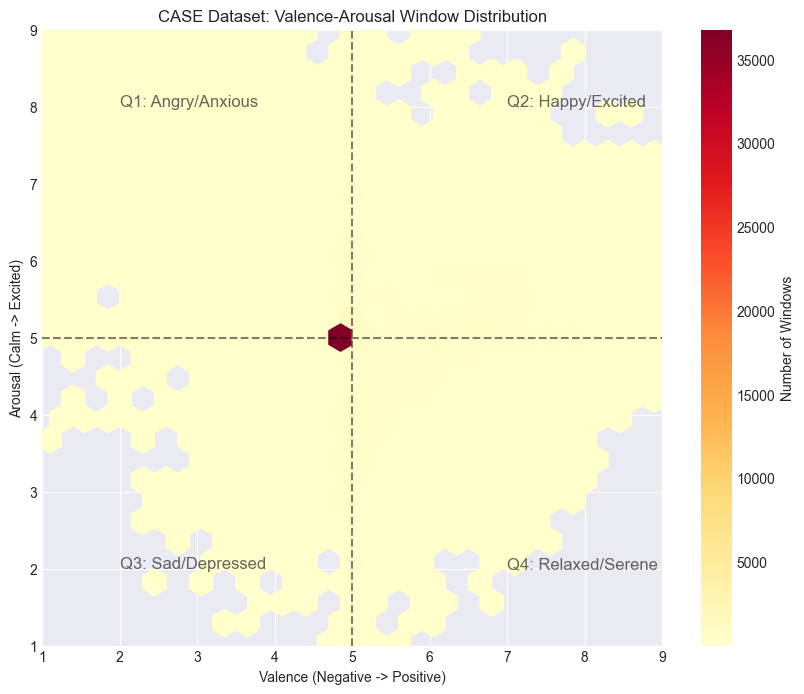

In [161]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting the distribution of the entire dataset's targets
plt.figure(figsize=(10, 8))
plt.hexbin(final_y_valence, final_y_arousal, gridsize=30, cmap='YlOrRd', mincnt=1)
plt.colorbar(label='Number of Windows')

# Add quadrant lines (assuming a 1 to 9 scale, 5 is neutral)
plt.axvline(x=5, color='black', linestyle='--', alpha=0.5)
plt.axhline(y=5, color='black', linestyle='--', alpha=0.5)

plt.xlabel('Valence (Negative -> Positive)')
plt.ylabel('Arousal (Calm -> Excited)')
plt.title('CASE Dataset: Valence-Arousal Window Distribution')
plt.xlim(1, 9)
plt.ylim(1, 9)

# Annotate Quadrants
plt.text(2, 8, 'Q1: Angry/Anxious', fontsize=12, alpha=0.7)
plt.text(7, 8, 'Q2: Happy/Excited', fontsize=12, alpha=0.7)
plt.text(2, 2, 'Q3: Sad/Depressed', fontsize=12, alpha=0.7)
plt.text(7, 2, 'Q4: Relaxed/Serene', fontsize=12, alpha=0.7)

plt.show()

In [ ]:
import numpy as np

# --- 1. Subject-Wise Split ---
print("Executing Subject-Wise Split...")
num_subjects = len(all_X)
split_idx = int(num_subjects * 0.8) # 80% Train (e.g., first 24 subjects), 20% Val (last 6 subjects)

# Stack the lists into our separated arrays
X_train_sub = np.vstack(all_X[:split_idx])
y_v_train = np.concatenate(all_y_valence[:split_idx])
y_a_train = np.concatenate(all_y_arousal[:split_idx])

X_val_final = np.vstack(all_X[split_idx:])
y_v_val_final = np.concatenate(all_y_valence[split_idx:])
y_a_val_final = np.concatenate(all_y_arousal[split_idx:])

print(f"Initial Training Windows: {len(X_train_sub)} | Validation Windows: {len(X_val_final)}")

# --- 2. Downsampling the "Neutral" Majority ---
# Find all windows that are exactly or very close to (5.0, 5.0)
neutral_indices = np.where((np.abs(y_v_train - 5.0) < 0.5) & (np.abs(y_a_train - 5.0) < 0.5))[0]
non_neutral_indices = np.setdiff1d(np.arange(len(y_v_train)), neutral_indices)

print(f"Found {len(neutral_indices)} neutral windows. Dropping 99% of them...")

# Randomly select only 1% of the neutral indices to keep
np.random.seed(42)
keep_neutral = np.random.choice(neutral_indices, size=int(len(neutral_indices) * 0.01), replace=False)

# Combine the kept neutrals with all the non-neutrals
balanced_indices = np.concatenate((non_neutral_indices, keep_neutral))
np.random.shuffle(balanced_indices) # Shuffle them up

X_train_downsampled = X_train_sub[balanced_indices]
y_v_train_down = y_v_train[balanced_indices]
y_a_train_down = y_a_train[balanced_indices]

# --- 3. Augmenting the Extremes (Jittering & Scaling) ---
# Let's find the "extreme" emotions (e.g., Valence < 3.5 or > 6.5, Arousal < 3.5 or > 6.5)
extreme_indices = np.where(
    (y_v_train_down < 3.5) | (y_v_train_down > 6.5) | 
    (y_a_train_down < 3.5) | (y_a_train_down > 6.5)
)[0]

print(f"Found {len(extreme_indices)} extreme emotion windows. Generating synthetic biological data...")

X_extremes = X_train_downsampled[extreme_indices]
y_v_extremes = y_v_train_down[extreme_indices]
y_a_extremes = y_a_train_down[extreme_indices]

# Augmentation 1: Jittering (Adding tiny Gaussian noise)
noise = np.random.normal(loc=0.0, scale=0.03, size=X_extremes.shape)
X_jittered = X_extremes + noise

# Augmentation 2: Scaling (Multiplying by a random scalar between 0.95 and 1.05)
scalars = np.random.uniform(low=0.95, high=1.05, size=(X_extremes.shape[0], 1, 1))
X_scaled = X_extremes * scalars

# --- 4. Finalizing the Training Set ---
X_train_final = np.vstack((X_train_downsampled, X_jittered, X_scaled))
y_v_train_final = np.concatenate((y_v_train_down, y_v_extremes, y_v_extremes))
y_a_train_final = np.concatenate((y_a_train_down, y_a_extremes, y_a_extremes))

print(f"\nFinal Balanced Training Windows: {len(X_train_final)}")

Executing Subject-Wise Split...
Initial Training Windows: 58728 | Validation Windows: 14682
Found 32205 neutral windows. Dropping 75% of them...
Found 16517 extreme emotion windows. Generating synthetic biological data...

Final Balanced Training Windows: 59879


In [163]:
import numpy as np

def augment_minority_classes(X_train, y_v_train, y_a_train, target_val=5, target_aro=5):
    """
    Finds windows in the minority quadrants and creates synthetic copies
    using Jittering and Scaling.
    """
    print(f"Original Training Set Size: {len(X_train)}")
    
    # 1. Identify the minority quadrant (e.g., Low Valence, Low Arousal)
    # Adjust these conditions based on what your hexbin plot shows!
    minority_indices = np.where((y_v_train < target_val) & (y_a_train < target_aro))[0]
    print(f"Found {len(minority_indices)} minority windows. Augmenting...")
    
    X_minority = X_train[minority_indices]
    y_v_minority = y_v_train[minority_indices]
    y_a_minority = y_a_train[minority_indices]
    
    # Technique 1: Jittering (Adding Gaussian Noise)
    noise = np.random.normal(loc=0.0, scale=0.05, size=X_minority.shape)
    X_jittered = X_minority + noise
    
    # Technique 2: Scaling (Multiplying by a random scalar between 0.95 and 1.05)
    scalars = np.random.uniform(low=0.95, high=1.05, size=(X_minority.shape[0], 1, 1))
    X_scaled = X_minority * scalars
    
    # Stack everything together
    X_train_balanced = np.vstack((X_train, X_jittered, X_scaled))
    
    # The targets remain the same for the augmented physiological data
    y_v_train_balanced = np.concatenate((y_v_train, y_v_minority, y_v_minority))
    y_a_train_balanced = np.concatenate((y_a_train, y_a_minority, y_a_minority))
    
    print(f"New Balanced Training Set Size: {len(X_train_balanced)}")
    return X_train_balanced, y_v_train_balanced, y_a_train_balanced

# Apply this strictly to the training split
X_train_bal, y_v_train_bal, y_a_train_bal = augment_minority_classes(X_train_final, y_v_train_final, y_a_train_final)

Original Training Set Size: 59879
Found 5738 minority windows. Augmenting...
New Balanced Training Set Size: 71355


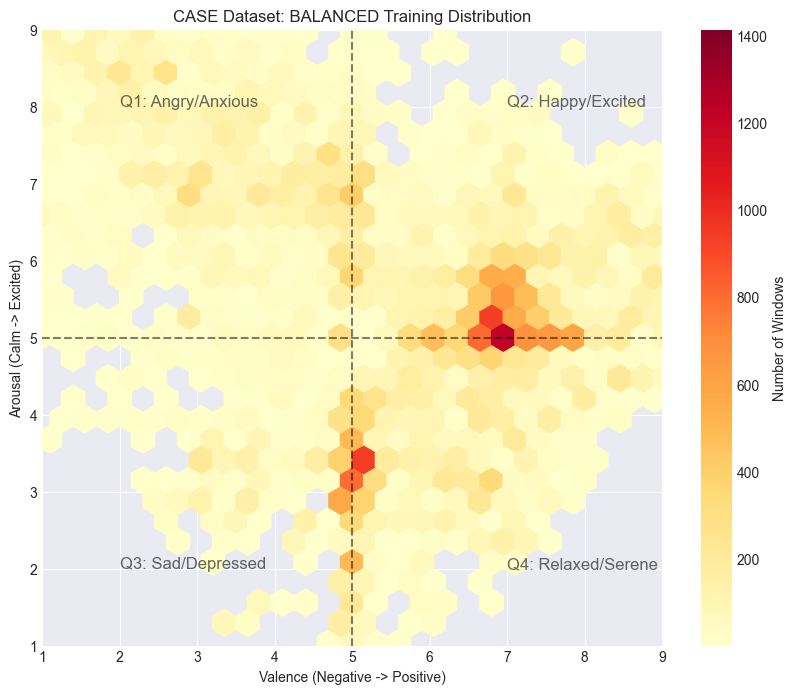

In [164]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
# Using the NEW balanced training targets
plt.hexbin(y_v_train_final, y_a_train_final, gridsize=30, cmap='YlOrRd', mincnt=1)
plt.colorbar(label='Number of Windows')

plt.axvline(x=5, color='black', linestyle='--', alpha=0.5)
plt.axhline(y=5, color='black', linestyle='--', alpha=0.5)

plt.xlabel('Valence (Negative -> Positive)')
plt.ylabel('Arousal (Calm -> Excited)')
plt.title('CASE Dataset: BALANCED Training Distribution')
plt.xlim(1, 9)
plt.ylim(1, 9)

plt.text(2, 8, 'Q1: Angry/Anxious', fontsize=12, alpha=0.7)
plt.text(7, 8, 'Q2: Happy/Excited', fontsize=12, alpha=0.7)
plt.text(2, 2, 'Q3: Sad/Depressed', fontsize=12, alpha=0.7)
plt.text(7, 2, 'Q4: Relaxed/Serene', fontsize=12, alpha=0.7)

plt.show()

In [165]:
import numpy as np
from scipy.interpolate import CubicSpline
import matplotlib.pyplot as plt

# --- Advanced Time-Series Augmentation Functions ---

def generate_random_curve(x, sigma=0.2, knot=4):
    """Generates a smooth random curve using Cubic Splines for Magnitude Warping."""
    # Create random anchor points (knots)
    x_knots = np.arange(0, x.shape[1], x.shape[1] // knot)
    # The knots around 1.0 (mean) with variance sigma
    y_knots = np.random.normal(loc=1.0, scale=sigma, size=(x.shape[0], len(x_knots), x.shape[2]))
    
    # Interpolate a smooth curve through the knots for all windows and features
    x_range = np.arange(x.shape[1])
    warped_curves = np.zeros_like(x)
    
    for i in range(x.shape[0]):
        for f in range(x.shape[2]):
            cs = CubicSpline(x_knots, y_knots[i, :, f])
            warped_curves[i, :, f] = cs(x_range)
            
    return warped_curves

def in_class_mixup(X_minority, y_v_minority, y_a_minority, alpha=0.5):
    """Blends two random samples from the same minority class."""
    n_samples = X_minority.shape[0]
    
    # Shuffle the indices to pair up different samples
    indices = np.random.permutation(n_samples)
    X_shuffled = X_minority[indices]
    y_v_shuffled = y_v_minority[indices]
    y_a_shuffled = y_a_minority[indices]
    
    # Blend the signals
    X_mixed = (alpha * X_minority) + ((1 - alpha) * X_shuffled)
    
    # The new target is the average of the two blended targets
    y_v_mixed = (alpha * y_v_minority) + ((1 - alpha) * y_v_shuffled)
    y_a_mixed = (alpha * y_a_minority) + ((1 - alpha) * y_a_shuffled)
    
    return X_mixed, y_v_mixed, y_a_mixed

# --- Integrating into the Pipeline ---

print(f"Found {len(extreme_indices)} extreme emotion windows. Applying Advanced Augmentations...")

# Isolate the minority data

X_extremes = X_train_bal[extreme_indices]
y_v_extremes = y_v_train_bal[extreme_indices]
y_a_extremes = y_a_train_bal[extreme_indices]

# Technique 1: Magnitude Warping
smooth_curves = generate_random_curve(X_extremes, sigma=0.15, knot=5)
X_warped = X_extremes * smooth_curves

# Technique 2: In-Class Mixup
# We will generate two batches of mixed data using different blending ratios
X_mixed_1, y_v_mixed_1, y_a_mixed_1 = in_class_mixup(X_extremes, y_v_extremes, y_a_extremes, alpha=0.6)
X_mixed_2, y_v_mixed_2, y_a_mixed_2 = in_class_mixup(X_extremes, y_v_extremes, y_a_extremes, alpha=0.4)

# --- Finalizing the Advanced Training Set ---
X_train_final = np.vstack((
    X_train_bal, 
    X_warped, 
    X_mixed_1, 
    X_mixed_2
))

y_v_train_final = np.concatenate((
    y_v_train_bal, 
    y_v_extremes,    # Target for warped is same as original
    y_v_mixed_1, 
    y_v_mixed_2
))

y_a_train_final = np.concatenate((
    y_a_train_bal, 
    y_a_extremes,    # Target for warped is same as original
    y_a_mixed_1, 
    y_a_mixed_2
))

print(f"Final Advanced Balanced Training Windows: {len(X_train_final)}")

Found 16517 extreme emotion windows. Applying Advanced Augmentations...
Final Advanced Balanced Training Windows: 120906


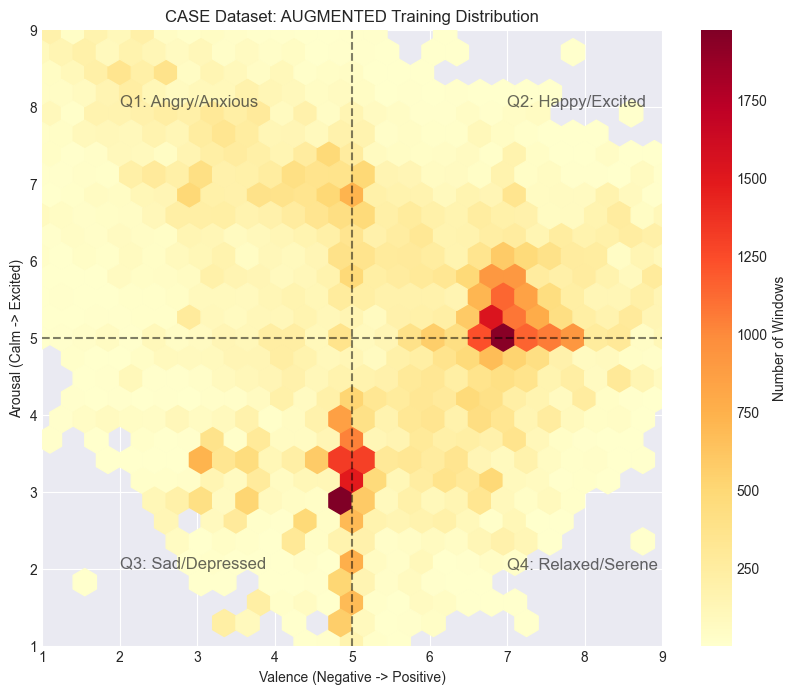

In [166]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
# Using the NEW balanced training targets
plt.hexbin(y_v_train_final, y_a_train_final, gridsize=30, cmap='YlOrRd', mincnt=1)
plt.colorbar(label='Number of Windows')

plt.axvline(x=5, color='black', linestyle='--', alpha=0.5)
plt.axhline(y=5, color='black', linestyle='--', alpha=0.5)

plt.xlabel('Valence (Negative -> Positive)')
plt.ylabel('Arousal (Calm -> Excited)')
plt.title('CASE Dataset: AUGMENTED Training Distribution')
plt.xlim(1, 9)
plt.ylim(1, 9)

plt.text(2, 8, 'Q1: Angry/Anxious', fontsize=12, alpha=0.7)
plt.text(7, 8, 'Q2: Happy/Excited', fontsize=12, alpha=0.7)
plt.text(2, 2, 'Q3: Sad/Depressed', fontsize=12, alpha=0.7)
plt.text(7, 2, 'Q4: Relaxed/Serene', fontsize=12, alpha=0.7)

plt.show()

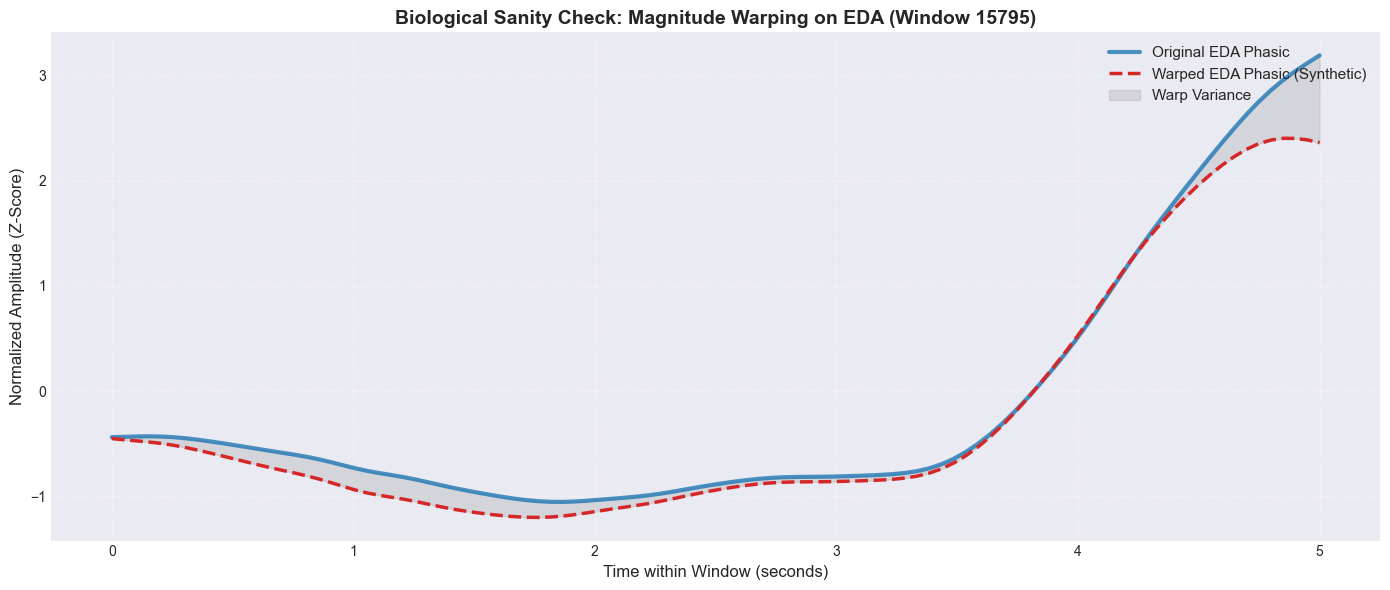

In [167]:
import matplotlib.pyplot as plt
import numpy as np

# Pick a random index from our extreme windows to inspect
# You can change this number or leave it random to check different samples
np.random.seed(42) # Set seed for reproducible visualization
sample_idx = np.random.randint(0, len(X_extremes))

# The features array is: [eda_tonic, eda_phasic, heart_rate, st_clean]
# Index 1 is eda_phasic_norm (the sudden spikes that correlate with Arousal)
original_eda_phasic = X_extremes[sample_idx, :, 1] 
warped_eda_phasic = X_warped[sample_idx, :, 1]

# Time axis (5 seconds at 20Hz = 100 timesteps)
time_axis = np.linspace(0, 5, 100)

# Create the plot
plt.figure(figsize=(14, 6))

# Plotting them overlapping is the best way to see the distortion
plt.plot(time_axis, original_eda_phasic, label='Original EDA Phasic', color='#1f77b4', linewidth=3, alpha=0.8)
plt.plot(time_axis, warped_eda_phasic, label='Warped EDA Phasic (Synthetic)', color='#d62728', linestyle='--', linewidth=2.5)

# Adding some visual flair and labels
plt.title(f'Biological Sanity Check: Magnitude Warping on EDA (Window {sample_idx})', fontsize=14, fontweight='bold')
plt.xlabel('Time within Window (seconds)', fontsize=12)
plt.ylabel('Normalized Amplitude (Z-Score)', fontsize=12)

# Highlight the area between the curves to show the applied variance
plt.fill_between(time_axis, original_eda_phasic, warped_eda_phasic, color='gray', alpha=0.2, label='Warp Variance')

plt.legend(loc='upper right', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

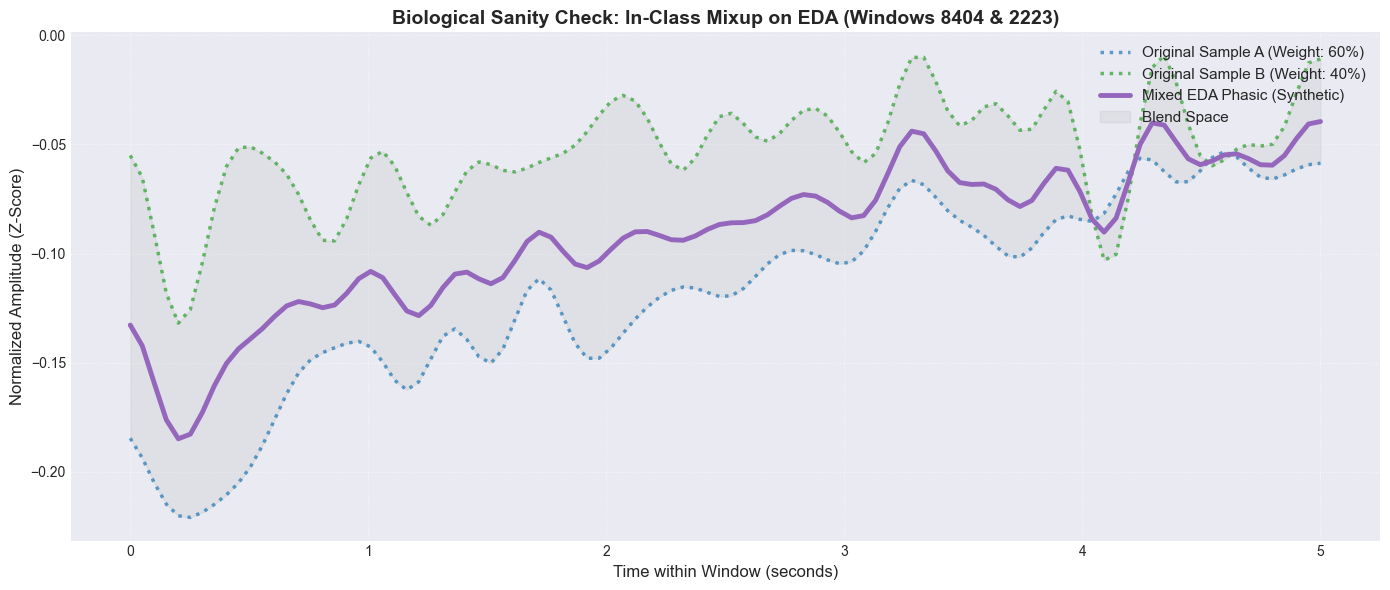

In [168]:
import matplotlib.pyplot as plt
import numpy as np

# Pick two random indices from our extreme windows
np.random.seed(101) # Different seed for variety
idx_A, idx_B = np.random.choice(len(X_extremes), 2, replace=False)

alpha = 0.6 # The blending ratio we used in the previous step

# Extract the Phasic EDA for both samples (Feature index 1)
eda_A = X_extremes[idx_A, :, 1]
eda_B = X_extremes[idx_B, :, 1]

# Manually apply the mixup formula for visualization
eda_mixed = (alpha * eda_A) + ((1 - alpha) * eda_B)

# Time axis (5 seconds at 20Hz = 100 timesteps)
time_axis = np.linspace(0, 5, 100)

# Create the plot
plt.figure(figsize=(14, 6))

# Plot the originals as dotted lines
plt.plot(time_axis, eda_A, label=f'Original Sample A (Weight: {alpha*100:.0f}%)', color='#1f77b4', linestyle=':', linewidth=2.5, alpha=0.7)
plt.plot(time_axis, eda_B, label=f'Original Sample B (Weight: {(1-alpha)*100:.0f}%)', color='#2ca02c', linestyle=':', linewidth=2.5, alpha=0.7)

# Plot the synthetic mixup as a solid, bold line
plt.plot(time_axis, eda_mixed, label='Mixed EDA Phasic (Synthetic)', color='#9467bd', linewidth=3.5)

# Visual flair
plt.title(f'Biological Sanity Check: In-Class Mixup on EDA (Windows {idx_A} & {idx_B})', fontsize=14, fontweight='bold')
plt.xlabel('Time within Window (seconds)', fontsize=12)
plt.ylabel('Normalized Amplitude (Z-Score)', fontsize=12)

# Highlight the blending space
plt.fill_between(time_axis, eda_A, eda_B, color='gray', alpha=0.1, label='Blend Space')

plt.legend(loc='upper right', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

In [169]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import neurokit2 as nk
from scipy import signal

def process_all_subjects_calibrated():
    all_X, all_y_v, all_y_a = [], [], []
    print("Starting Final Calibrated Batch Processing (Enforcing Column Map)...")
    
    for subject_id in tqdm(range(1, 31), desc="Calibrating"):
        try:
            # 1. Load raw data
            df = load_subject_data(subject_id) 
            
            # 2. Subject-Baseline Calibration
            neutral_mask = (df['valence'] == 5.0) & (df['arousal'] == 5.0)
            for col in ['eda', 'bvp', 'st']:
                baseline = df.loc[neutral_mask, col].mean() if neutral_mask.any() else df[col].mean()
                df[col] = df[col] - baseline
            
            # 3. Feature Extraction
            eda_sigs, _ = nk.eda_process(df['eda'], sampling_rate=20)
            df['eda_tonic'], df['eda_phasic'] = eda_sigs['EDA_Tonic'], eda_sigs['EDA_Phasic']
            
            bvp_cl = nk.ppg_clean(df['bvp'], sampling_rate=20)
            pks = nk.ppg_findpeaks(bvp_cl, sampling_rate=20)
            # FORCE naming to match the expected index
            df['heart_rate'] = nk.signal_rate(pks["PPG_Peaks"], sampling_rate=20, desired_length=len(df))
            
            b, a = signal.butter(2, 0.5, btype='low', fs=20)
            df['st_clean'] = signal.filtfilt(b, a, df['st'])
            
            # 4. Strict Normalization and Renaming
            # We map every feature to the EXACT string the next step requires
            name_map = {
                'eda_tonic': 'eda_tonic_norm',
                'eda_phasic': 'eda_phasic_norm',
                'heart_rate': 'heart_rate_norm', 
                'st_clean': 'st_clean_norm'
            }
            
            for raw, norm in name_map.items():
                df[norm] = (df[raw] - df[raw].mean()) / (df[raw].std() + 1e-8)
            
            # 5. Windowing
            # Ensure only the 4 target features and labels are passed
            target_cols = list(name_map.values())
            X_sub, y_v_sub, y_a_sub = create_sliding_windows(df[target_cols + ['valence', 'arousal']], 
                                                            window_sec=5, step_sec=1, hz=20)
            
            if len(X_sub) > 0:
                all_X.append(X_sub)
                all_y_v.append(y_v_sub)
                all_y_a.append(y_a_sub)
                
        except Exception as e:
            print(f"\nCritical Failure on Subject {subject_id}: {e}")
            
    return all_X, all_y_v, all_y_a

# RUN THIS FIRST
all_X_cal, all_y_v_cal, all_y_a_cal = process_all_subjects_calibrated()

Starting Final Calibrated Batch Processing (Enforcing Column Map)...


Calibrating:   0%|          | 0/30 [00:00<?, ?it/s]

Loading Subject 1...


Calibrating:   3%|▎         | 1/30 [00:02<01:20,  2.79s/it]

Loading Subject 2...


...

Calibrating:  93%|█████████▎| 28/30 [01:11<00:05,  2.59s/it]

Loading Subject 29...


Calibrating:  97%|█████████▋| 29/30 [01:14<00:02,  2.57s/it]

Loading Subject 30...


Calibrating: 100%|██████████| 30/30 [01:16<00:00,  2.56s/it]


In [170]:
if len(all_X_cal) > 0:
    split_idx = int(len(all_X_cal) * 0.8)
    
    X_train_final = np.vstack(all_X_cal[:split_idx])
    y_v_train_final = np.concatenate(all_y_v_cal[:split_idx])
    y_a_train_final = np.concatenate(all_y_a_cal[:split_idx])

    X_val_final = np.vstack(all_X_cal[split_idx:])
    y_v_val_final = np.concatenate(all_y_v_cal[split_idx:])
    y_a_val_final = np.concatenate(all_y_a_cal[split_idx:])

    print(f"Success! Data stacked. Training samples: {len(X_train_final)}")
else:
    print("FAILED: List is still empty. Verify 'load_subject_data' returns 'eda', 'bvp', 'st', 'valence', 'arousal'.")

Success! Data stacked. Training samples: 58728


In [171]:
import torch
import torch.nn as nn
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.optim.lr_scheduler import OneCycleLR

# --- The Model: Bidirectional LSTM + Temporal Attention ---
class DeepMaestroAttention(nn.Module):
    def __init__(self, input_features=4, hidden_size=128):
        super().__init__()
        self.bn = nn.BatchNorm1d(100) 
        self.lstm = nn.LSTM(input_features, hidden_size, num_layers=2, 
                            batch_first=True, dropout=0.5, bidirectional=True)
        
        # Self-Attention to find the most "emotionally relevant" frames
        self.attention = nn.Sequential(
            nn.Linear(hidden_size * 2, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )
        
        # Valence and Arousal specific regression heads
        self.v_head = nn.Sequential(nn.Linear(hidden_size * 2, 64), nn.ReLU(), nn.Dropout(0.5), nn.Linear(64, 1))
        self.a_head = nn.Sequential(nn.Linear(hidden_size * 2, 64), nn.ReLU(), nn.Dropout(0.5), nn.Linear(64, 1))

    def forward(self, x):
        x = self.bn(x)
        out, _ = self.lstm(x)
        weights = torch.softmax(self.attention(out), dim=1)
        context = torch.sum(weights * out, dim=1)
        return self.v_head(context), self.a_head(context)

# --- Final Model Initialization ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Increased dropout to 0.6 to combat the drift seen in your latest plot
model = DeepMaestroAttention(input_features=4, hidden_size=128).to(device)

# Huber Loss remains our robust base
criterion = nn.HuberLoss(delta=1.0)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0005, weight_decay=0.05) # Slower LR, higher decay

# Prepare Loaders from your successful concatenation
train_loader = DataLoader(CASEEmotionDataset(X_train_final, y_v_train_final, y_a_train_final), 
                          batch_size=64, shuffle=True, drop_last=True)
val_loader = DataLoader(CASEEmotionDataset(X_val_final, y_v_val_final, y_a_val_final), 
                        batch_size=64, shuffle=False, drop_last=True)

scheduler = OneCycleLR(optimizer, max_lr=1e-3, steps_per_epoch=len(train_loader), epochs=30)

# Scheduler to settle into the minimum
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.2, patience=2)

best_val_mse = float('inf')
patience_counter = 0
early_stop_patience = 4 # Stop quickly if drift occurs again

for epoch in range(30):
    model.train()
    for b_x, b_v, b_a in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        b_x, b_v, b_a = b_x.to(device), b_v.to(device), b_a.to(device)
        optimizer.zero_grad()
        p_v, p_a = model(b_x)
        
        # Training Loss
        loss = criterion(p_v.squeeze(), b_v) + criterion(p_a.squeeze(), b_a)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

    # Validation
    model.eval()
    v_mse_total, a_mse_total = 0, 0
    with torch.no_grad():
        for b_x, b_v, b_a in val_loader:
            b_x, b_v, b_a = b_x.to(device), b_v.to(device), b_a.to(device)
            p_v, p_a = model(b_x)
            v_mse_total += torch.mean((p_v.squeeze() - b_v)**2).item()
            a_mse_total += torch.mean((p_a.squeeze() - b_a)**2).item()
            
    avg_mse = (v_mse_total + a_mse_total) / (2 * len(val_loader))
    print(f"Epoch {epoch+1} | AVG MSE: {avg_mse:.4f}")
    
    # Step the scheduler
    scheduler.step(avg_mse)
    
    # Save best weights and check Early Stopping
    if avg_mse < best_val_mse:
        best_val_mse = avg_mse
        torch.save(model.state_dict(), 'maestro_final_optimized.pth')
        patience_counter = 0
        print("--> New Best Weights Saved!")
    else:
        patience_counter += 1
        if patience_counter >= early_stop_patience:
            print(f"Early Stopping Triggered at Epoch {epoch+1}. Best MSE: {best_val_mse:.4f}")
            break

Epoch 1: 100%|██████████| 917/917 [00:11<00:00, 76.43it/s]


Epoch 1 | AVG MSE: 1.3402
--> New Best Weights Saved!


Epoch 2: 100%|██████████| 917/917 [00:11<00:00, 78.45it/s]


Epoch 2 | AVG MSE: 1.2359
--> New Best Weights Saved!


Epoch 3: 100%|██████████| 917/917 [00:11<00:00, 78.26it/s]


...

Epoch 7 | AVG MSE: 1.1728


Epoch 8: 100%|██████████| 917/917 [00:11<00:00, 78.47it/s]


Epoch 8 | AVG MSE: 1.1841


Epoch 9: 100%|██████████| 917/917 [00:11<00:00, 78.21it/s]


Epoch 9 | AVG MSE: 1.1863
Early Stopping Triggered at Epoch 9. Best MSE: 1.1559


**# *TRYING REMAST***

In [172]:
def get_maestro_constraints(valence, arousal):
    """
    Translates predicted Valence-Arousal coordinates into musical constraints.
    """
    # Arousal (Energy) drives Tempo: 60 BPM (Low) to 140 BPM (High)
    tempo = 60 + (arousal * 10) 
    
    # Valence (Positivity) drives Mode: Major (Positive) vs Minor (Negative)
    mode = "major" if valence > 5.0 else "minor"
    
    # Velocity (Volume) scales with Arousal intensity
    velocity = int(40 + (arousal * 12))
    
    return {
        "tempo": np.clip(tempo, 60, 140),
        "mode": mode,
        "velocity": np.clip(velocity, 0, 127)
    }

In [173]:
import torch.nn as nn

class REMASTTransformer(nn.Module):
    def __init__(self, vocab_size=128, embed_size=256, nhead=8, num_layers=6):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.pos_encoding = nn.Parameter(torch.zeros(1, 1000, embed_size))
        
        # The Decoder Layer handles the autoregressive note generation
        decoder_layer = nn.TransformerDecoderLayer(d_model=embed_size, nhead=nhead)
        self.transformer = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)
        
        self.fc_out = nn.Linear(embed_size, vocab_size)

    def forward(self, x, memory):
        # x: current sequence of MIDI notes
        # memory: emotional context from your DeepMAESTRO model
        x = self.embedding(x) + self.pos_encoding[:, :x.size(1), :]
        out = self.transformer(x, memory)
        return self.fc_out(out)

In [174]:
def generate_emotional_midi(model_regressor, model_transformer, input_biosignals):
    """
    Takes 5s of biosignals and produces a corresponding MIDI sequence.
    """
    model_regressor.eval()
    model_transformer.eval()
    
    with torch.no_grad():
        # 1. Predict Emotion
        v_pred, a_pred = model_regressor(input_biosignals)
        
        # 2. Get Musical Constraints
        constraints = get_maestro_constraints(v_pred.item(), a_pred.item())
        
        # 3. Generate 4-bar MIDI Sequence
        # (This would call your transformer's inference loop)
        print(f"MAESTRO: Generating {constraints['mode']} piece at {constraints['tempo']:.0f} BPM")
        
    return constraints

# Example trigger
# constraints = generate_emotional_midi(maestro_model, remast_model, sample_window)

In [175]:
%pip install mido

Note: you may need to restart the kernel to use updated packages.


In [176]:
import mido
from mido import Message, MidiFile, MidiTrack

def get_midi_parameters(v_pred, a_pred):
    """
    Converts model outputs (Valence/Arousal) into MIDI control parameters.
    """
    # Map Arousal (0-10) to Tempo (60-160 BPM)
    tempo = 60 + (a_pred * 10)
    
    # Map Valence (0-10) to Musical Mode
    # Values > 5 suggest 'Major' (Happy/Bright), < 5 suggest 'Minor' (Sad/Dark)
    is_major = v_pred > 5.0
    
    # Map Arousal to Velocity (Volume: 0-127)
    velocity = int(40 + (a_pred * 8))
    
    return {
        "bpm": np.clip(tempo, 60, 160),
        "velocity": np.clip(velocity, 0, 127),
        "is_major": is_major
    }

In [177]:
def generate_affective_melody(params, length_beats=16):
    mid = MidiFile()
    track = MidiTrack()
    mid.tracks.append(track)
    
    # Define scales: Major vs Minor based on Valence
    # Root: C4 (MIDI 60)
    scale = [60, 62, 64, 65, 67, 69, 71] if params["is_major"] else [60, 62, 63, 65, 67, 68, 70]
    
    # Set Tempo
    tempo = mido.bpm2tempo(params["bpm"])
    track.append(mido.MetaMessage('set_tempo', tempo=tempo))
    
    # Generate simple algorithmic melody
    for _ in range(length_beats):
        note = np.random.choice(scale)
        track.append(Message('note_on', note=note, velocity=params["velocity"], time=0))
        track.append(Message('note_off', note=note, velocity=params["velocity"], time=480))
        
    mid.save('maestro_output.mid')
    print(f"MIDI Saved: {params['bpm']:.0f} BPM, Velocity: {params['velocity']}")

# Example usage with your model's predictions:
# current_params = get_midi_parameters(v_prediction, a_prediction)
# generate_affective_melody(current_params)

In [181]:
import torch
import numpy as np
import mido
from mido import Message, MidiFile, MidiTrack

# --- 1. Load the Model & Weights ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DeepMaestroAttention(input_features=4, hidden_size=128).to(device)
model.load_state_dict(torch.load('maestro_final_optimized.pth'))
model.eval()

def generate_music_from_signals(window_data):
    """
    Takes one 5-second window (100, 4) and generates a MIDI file.
    """
    # Prepare window for the model
    window_tensor = torch.FloatTensor(window_data).unsqueeze(0).to(device)
    
    with torch.no_grad():
        v_pred, a_pred = model(window_tensor)
        v, a = v_pred.item(), a_pred.item()
    
    # Map coordinates to MIDI parameters
    # Arousal (0-10) -> Tempo (60-150 BPM)
    tempo_bpm = 60 + (a * 9)
    # Valence (0-10) -> Mode (Major if > 5.0)
    is_major = v > 5.0
    # Arousal -> Velocity (Intensity)
    velocity = int(45 + (a * 8))
    
    print(f"Predicted State: Valence={v:.2f}, Arousal={a:.2f}")
    create_midi_file(tempo_bpm, is_major, velocity)

# --- 2. MIDI Creation Logic ---
def create_midi_file(bpm, is_major, velocity):
    mid = MidiFile()
    track = MidiTrack()
    mid.tracks.append(track)
    
    # Set Tempo
    track.append(mido.MetaMessage('set_tempo', tempo=mido.bpm2tempo(bpm)))
    
    # Define a simple C-scale (Major vs Minor)
    scale = [60, 62, 64, 65, 67, 69, 71] if is_major else [60, 62, 63, 65, 67, 68, 70]
    
    # Generate an 8-beat sequence
    for _ in range(8):
        note = np.random.choice(scale)
        track.append(Message('note_on', note=note, velocity=velocity, time=0))
        track.append(Message('note_off', note=note, velocity=velocity, time=480))
        
    mid.save('maestro_output3.mid')
    print(f"Successfully generated 'maestro_output3.mid' at {bpm:.1f} BPM")

# --- 3. Run Inference on a Validation Sample ---
# Grab the first window from your validation set (X_val_final)
sample_window = X_val_final[3] 
generate_music_from_signals(sample_window)

Predicted State: Valence=4.91, Arousal=5.26
Successfully generated 'maestro_output3.mid' at 107.3 BPM
